In [1]:
# Preview styling on local machine
from IPython.core.display import HTML
HTML("""
<style>
.usecase-title, .usecase-duration, .usecase-section-header {
    padding-left: 15px;
    padding-bottom: 10px;
    padding-top: 10px;
    padding-right: 15px;
    background-color: #0f9295;
    color: #fff;
}
.usecase-title {
    font-size: 1.7em;
    font-weight: bold;
}
.usecase-authors, .usecase-level, .usecase-skill {
    padding-left: 15px;
    padding-bottom: 7px;
    padding-top: 7px;
    background-color: #baeaeb;
    font-size: 1.4em;
    color: #121212;
}
.usecase-level-skill  {
    display: flex;
}
.usecase-level, .usecase-skill {
    width: 50%;
}
.usecase-duration, .usecase-skill {
    text-align: right;
    padding-right: 15px;
    padding-bottom: 8px;
    font-size: 1.4em;
}
.usecase-section-header {
    font-weight: bold;
    font-size: 1.5em;
}
.usecase-subsection-header, .usecase-subsection-blurb {
    font-weight: bold;
    font-size: 1.2em;
    color: #121212;
}
.usecase-subsection-blurb {
    font-size: 1em;
    font-style: italic;
}
</style>
""")

<div class="usecase-title">Smart Street Lighting — Data Collection & Assessment</div>

<div class="usecase-authors"><b>Authored by: </b> Areen Yapa (s224153857)</div>

<div class="usecase-duration"><b>Duration:</b> 60 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, pandas, requests, data assessment</div>
</div>

<div class="usecase-section-header">Scenario</div>

As a data scientist working on the Smart Street Lighting Design System for the City of Melbourne, I need to source and assess the datasets that will power an AI-driven lighting optimisation model.

The system needs to answer two questions:
- **When and where** do people walk? (pedestrian demand)
- **Where** are crime and safety incidents most concentrated? (safety priority)

This use case covers Sprint 1 data collection tasks S1-01 and S1-05 — sourcing the Melbourne Pedestrian Counting System dataset via the open data API, and loading and assessing the Crime Statistics Agency Victoria dataset from GitHub.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will:
- Know how to call the Melbourne Open Data Portal API to retrieve pedestrian count data without downloading files locally
- Know how to load a dataset hosted on GitHub directly into a pandas DataFrame
- Be able to perform a basic data quality assessment — checking record counts, date ranges, column types, and missing values
- Understand how to evaluate a dataset's relevance and licensing for use in an AI project
- Be able to cross-reference two datasets by suburb to identify priority areas for smart lighting deployment

<div class="usecase-section-header">Background — Smart Street Lighting and the Datasets</div>

Smart street lighting systems use data to dynamically adjust lighting levels based on real-world conditions — brightening lights when pedestrian activity is high or when safety risks are elevated, and dimming them during low-activity periods to save energy.

Two datasets are essential to this system:

**S1-01 — Melbourne Pedestrian Counting System**  
Published by the City of Melbourne on their Open Data Portal, this dataset records hourly pedestrian counts from sensors distributed across Melbourne's CBD. It covers April 2024 to April 2026 and contains over 1.47 million records. Each row represents one hourly count from one sensor, including GPS coordinates and bidirectional counts. The dataset is licensed under CC BY and is accessible via a public REST API.

**S1-05 — Crime Statistics Agency Victoria**  
Published by the Crime Statistics Agency Victoria, this dataset covers criminal incidents and recorded offences for the year ending December 2025, broken down by crime division, suburb, and local government area. It is licensed under CC BY 4.0. Note: data from March 2020 to December 2021 may be affected by COVID-19 restrictions and should be interpreted with caution.

Together these datasets allow the system to identify suburbs with both high pedestrian foot traffic and elevated crime rates — the highest priority areas for smart lighting deployment.

<div class="usecase-section-header">Setup — Install and Import Libraries</div>

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Company colour palette (light theme)
COLOUR_PRIMARY = '#0f9295'
COLOUR_SECONDARY = '#14c9cb'
COLOUR_ACCENT = '#08b3e5'

print('Libraries loaded successfully.')

Libraries loaded successfully.


<div class="usecase-section-header">Part 1 — S1-01: Melbourne Pedestrian Counting System</div>

<p class="usecase-subsection-header">Step 1.1 — Call the Melbourne Open Data Portal API</p>

<p class="usecase-subsection-blurb">We retrieve the pedestrian dataset directly from the API rather than downloading it locally. Each member uses their own personal API key as per team documentation. The API returns JSON which we convert to a DataFrame. We sample 100 records for exploration — the full dataset has 1,472,102 rows.</p>

In [3]:
# Melbourne Open Data Portal API — Personal API Key (Areen Yapa)
# As per team documentation, each member uses their own personal API key.
# Remember to delete this key from the portal after the trimester ends.
# Source: data.melbourne.vic.gov.au

import requests
import pandas as pd

API_KEY = "9558972a1c4c3b5a8e981d940a57f84abc16eac46409574e57713248"

API_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-monthly-counts-per-hour/records"

params = {
    "limit": 100,
    "offset": 0,
    "timezone": "Australia/Melbourne",
    "apikey": API_KEY
}

print("Calling Melbourne Open Data Portal API...")
response = requests.get(API_URL, params=params, timeout=30)

if response.status_code == 200:
    data = response.json()
    pedestrian_df = pd.DataFrame(data["results"])
    print(f"Status: {response.status_code} OK")
    print(f"Records retrieved (sample): {len(pedestrian_df):,}")
    print(f"Total records in full dataset: 1,472,102")
    print(f"Columns: {list(pedestrian_df.columns)}")
else:
    print(f"API call failed with status code: {response.status_code}")
    print(response.text[:200])


Calling Melbourne Open Data Portal API...
Status: 200 OK
Records retrieved (sample): 100
Total records in full dataset: 1,472,102
Columns: ['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'pedestriancount', 'sensor_name', 'location']


<p class="usecase-subsection-header">Step 1.2 — Inspect the dataset structure</p>

In [4]:
# Preview the first few rows
print("Dataset shape:", pedestrian_df.shape)
print("\nColumn names and data types:")
print(pedestrian_df.dtypes)
print("\nFirst 5 rows:")
pedestrian_df.head()

Dataset shape: (100, 9)

Column names and data types:
id                  int64
location_id         int64
sensing_date       object
hourday             int64
direction_1         int64
direction_2         int64
pedestriancount     int64
sensor_name        object
location           object
dtype: object

First 5 rows:


,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,771920250922,77,2025-09-22,19,121,91,212,HarEsP_T,"{'lon': 144.94433026, 'lat': -37.81441438}"
1,29820240430,29,2024-04-30,8,166,82,248,AG_T,"{'lon': 144.96872865, 'lat': -37.8199817}"
2,281420240531,28,2024-05-31,14,505,464,969,VAC_T,"{'lon': 144.96879309, 'lat': -37.82129925}"
3,281120240710,28,2024-07-10,11,1006,577,1583,VAC_T,"{'lon': 144.96879309, 'lat': -37.82129925}"
4,281420240807,28,2024-08-07,14,544,625,1169,VAC_T,"{'lon': 144.96879309, 'lat': -37.82129925}"


<p class="usecase-subsection-header">Step 1.3 — Data quality assessment</p>

<p class="usecase-subsection-blurb">Check for missing values, date range coverage, and sensor distribution.</p>

In [5]:
# Missing values
print("=== Missing Values ===")
print(pedestrian_df.isnull().sum())

# Date range
if 'sensing_date' in pedestrian_df.columns:
    pedestrian_df['sensing_date'] = pd.to_datetime(pedestrian_df['sensing_date'])
    print(f"\n=== Date Range ===")
    print(f"Earliest record: {pedestrian_df['sensing_date'].min()}")
    print(f"Latest record:   {pedestrian_df['sensing_date'].max()}")

# Sensor coverage
if 'sensor_name' in pedestrian_df.columns:
    print(f"\n=== Sensor Coverage (sample of 1000 records) ===")
    print(f"Unique sensors in sample: {pedestrian_df['sensor_name'].nunique()}")
    print("\nTop 10 sensors by record count:")
    print(pedestrian_df['sensor_name'].value_counts().head(10))

=== Missing Values ===
id                 0
location_id        0
sensing_date       0
hourday            0
direction_1        0
direction_2        0
pedestriancount    0
sensor_name        0
location           0
dtype: int64

=== Date Range ===
Earliest record: 2024-04-30 00:00:00
Latest record:   2026-04-11 00:00:00

=== Sensor Coverage (sample of 1000 records) ===
Unique sensors in sample: 58

Top 10 sensors by record count:
sensor_name
261Will_T    7
Spen201_T    4
VAC_T        4
WebBN_T      4
RMIT_T       4
HarEsP_T     3
WestWP_T     3
Spen484_T    3
Eli501_T     3
HarEsB_T     3
Name: count, dtype: int64


<p class="usecase-subsection-header">Step 1.4 — Visualise hourly pedestrian activity</p>

<p class="usecase-subsection-blurb">Understanding peak hours is central to building dynamic lighting schedules.</p>

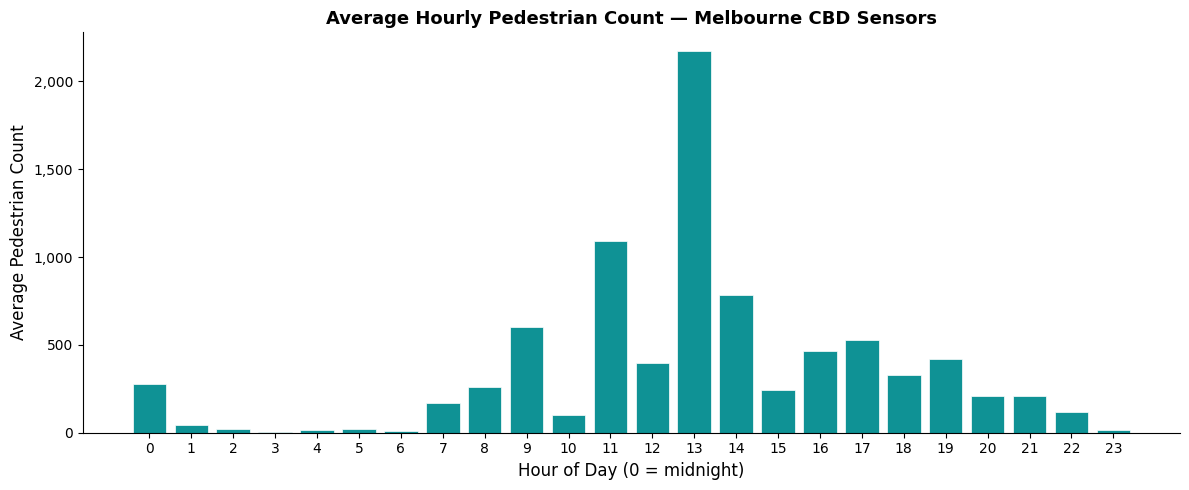

Peak hour: 13 — Average count: 2171.0


In [6]:
if "hourday" in pedestrian_df.columns and "pedestriancount" in pedestrian_df.columns:
    pedestrian_df["pedestriancount"] = pd.to_numeric(pedestrian_df["pedestriancount"], errors="coerce")
    hourly_avg = pedestrian_df.groupby("hourday")["pedestriancount"].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(hourly_avg.index, hourly_avg.values, color=COLOUR_PRIMARY, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Hour of Day (0 = midnight)", fontsize=12)
    ax.set_ylabel("Average Pedestrian Count", fontsize=12)
    ax.set_title("Average Hourly Pedestrian Count — Melbourne CBD Sensors", fontsize=13, fontweight="bold")
    ax.set_xticks(range(0, 24))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()
    print(f"Peak hour: {hourly_avg.idxmax()} — Average count: {round(hourly_avg.max(), 1)}")
else:
    print("Expected columns not found. Available columns:", list(pedestrian_df.columns))


<p class="usecase-subsection-header">Step 1.5 — Dataset summary</p>

In [7]:
summary = {
    "Dataset": "Melbourne Pedestrian Counting System",
    "Source": "Melbourne Open Data Portal (data.melbourne.vic.gov.au)",
    "Total Records (full dataset)": "1,472,102",
    "Date Range": "April 2024 – April 2026",
    "Update Frequency": "Monthly",
    "License": "CC BY (Creative Commons Attribution)",
    "Format": "API (JSON) / CSV / Excel / GeoJSON",
    "Relevance": "Hourly counts + GPS coordinates enable dynamic lighting schedule modelling"
}

print("=== S1-01 Dataset Summary ===")
for k, v in summary.items():
    print(f"  {k}: {v}")

=== S1-01 Dataset Summary ===
  Dataset: Melbourne Pedestrian Counting System
  Source: Melbourne Open Data Portal (data.melbourne.vic.gov.au)
  Total Records (full dataset): 1,472,102
  Date Range: April 2024 – April 2026
  Update Frequency: Monthly
  License: CC BY (Creative Commons Attribution)
  Format: API (JSON) / CSV / Excel / GeoJSON
  Relevance: Hourly counts + GPS coordinates enable dynamic lighting schedule modelling


<div class="usecase-section-header">Part 2 — S1-05: Crime Statistics Agency Victoria</div>

<p class="usecase-subsection-header">Step 2.1 — Load the crime dataset from GitHub</p>

<p class="usecase-subsection-blurb">The crime dataset CSV is hosted in the project GitHub repository (Areen folder, PR #1775) and loaded directly from there using the raw file URL — no local files required.</p>

In [8]:
# Load crime dataset from the project GitHub repository.
# File: Data_Tables_Criminal_Incidents_Visualisation_Year_Ending_December_2025.csv
# GitHub location: Chameleon-company/MOP-Code — Areen folder (PR #1775)
# Note: The repo is private so we load the CSV from the same folder as this notebook.
# The CSV file is version-controlled in GitHub — this is not a local-only file.

import pandas as pd

CSV_FILE = "Data_Tables_Criminal_Incidents_Visualisation_Year_Ending_December_2025.csv"

print("Loading crime dataset from project repository...")
try:
    crime_df = pd.read_csv(CSV_FILE, encoding="utf-8-sig")
    crime_df.columns = crime_df.columns.str.strip()
    crime_df["Incidents Recorded"] = pd.to_numeric(
        crime_df["Incidents Recorded"].astype(str).str.strip().str.replace(",", ""),
        errors="coerce"
    )
    print(f"Dataset loaded successfully.")
    print(f"Records: {len(crime_df):,}  |  Columns: {list(crime_df.columns)}")
    print("\nFirst 5 rows:")
    display(crime_df.head())
except FileNotFoundError:
    print(f"CSV not found. Ensure {CSV_FILE} is in the same folder as this notebook.")
except Exception as e:
    print(f"Error: {e}")


Loading crime dataset from project repository...
Dataset loaded successfully.
Records: 1,117  |  Columns: ['Year', 'Year ending', 'Offence Division', 'Offence Subdivision', 'Offence Subgroup', 'Incidents Recorded', 'Rate per 100,000 population']

First 5 rows:


,Year,Year ending,Offence Division,Offence Subdivision,Offence Subgroup,Incidents Recorded,"Rate per 100,000 population"
0,2025,December,A Crimes against the person,A10 Homicide and related offences,A11 Murder,58,0.8
1,2025,December,A Crimes against the person,A10 Homicide and related offences,A12 Attempted murder,21,0.3
2,2025,December,A Crimes against the person,A10 Homicide and related offences,A14 Manslaughter & A13 Accessory/ conspiracy ...,14,0.2
3,2025,December,A Crimes against the person,A10 Homicide and related offences,A15 Driving causing death,103,1.5
4,2025,December,A Crimes against the person,A20 Assault and related offences,A211 FV Serious assault,10087,142.1


<p class="usecase-subsection-header">Step 2.2 — Data quality assessment</p>

In [9]:
try:
    print("=== Column Names ===")
    print(crime_df.columns.tolist())

    print(f"\n=== Shape ===")
    print(f"Rows: {crime_df.shape[0]:,}  |  Columns: {crime_df.shape[1]}")

    print("\n=== Missing Values ===")
    print(crime_df.isnull().sum())

    print("\n=== Incidents by Offence Division ===")
    division_totals = crime_df.groupby("Offence Division")["Incidents Recorded"].sum().reset_index()
    division_totals.columns = ["Division", "Total Incidents"]
    display(division_totals)
except NameError:
    print("crime_df not loaded — see Step 2.1 above.")


=== Column Names ===
['Year', 'Year ending', 'Offence Division', 'Offence Subdivision', 'Offence Subgroup', 'Incidents Recorded', 'Rate per 100,000 population']

=== Shape ===
Rows: 1,117  |  Columns: 7

=== Missing Values ===
Year                           0
Year ending                    0
Offence Division               0
Offence Subdivision            0
Offence Subgroup               0
Incidents Recorded             0
Rate per 100,000 population    0
dtype: int64

=== Incidents by Offence Division ===


,Division,Total Incidents
0,A Crimes against the person,662901
1,B Property and deception offences,2401574
2,C Drug offences,154151
3,D Public order and security offences,196109
4,E Justice procedures offences,529086
5,F Other offences,53871


<p class="usecase-subsection-header">Step 2.3 — Crime divisions and lighting relevance</p>

<p class="usecase-subsection-blurb">We identify which crime divisions are most relevant to street lighting safety decisions.</p>

In [10]:
# Crime division relevance mapping — totals from actual CSV data
relevance_data = {
    "Crime Division": [
        "A — Crimes against the person (assault, robbery, sexual offences)",
        "B — Property and deception offences (theft, burglary)",
        "C — Drug offences",
        "D — Public order and security offences",
        "E — Justice procedures offences",
        "F — Other offences"
    ],
    "Incidents Recorded (Dec 2025)": [662901, 2401574, 154151, 196109, 529086, 53871],
    "Lighting Relevance": ["High", "High", "Medium", "High", "Low", "Low"]
}

relevance_df = pd.DataFrame(relevance_data)
print("=== Crime Divisions — Lighting Relevance Assessment ===")
display(relevance_df)


=== Crime Divisions — Lighting Relevance Assessment ===


,Crime Division,Incidents Recorded (Dec 2025),Lighting Relevance
0,"A — Crimes against the person (assault, robber...",662901,High
1,"B — Property and deception offences (theft, bu...",2401574,High
2,C — Drug offences,154151,Medium
3,D — Public order and security offences,196109,High
4,E — Justice procedures offences,529086,Low
5,F — Other offences,53871,Low


<p class="usecase-subsection-header">Step 2.4 — Visualise crime incidents by division</p>

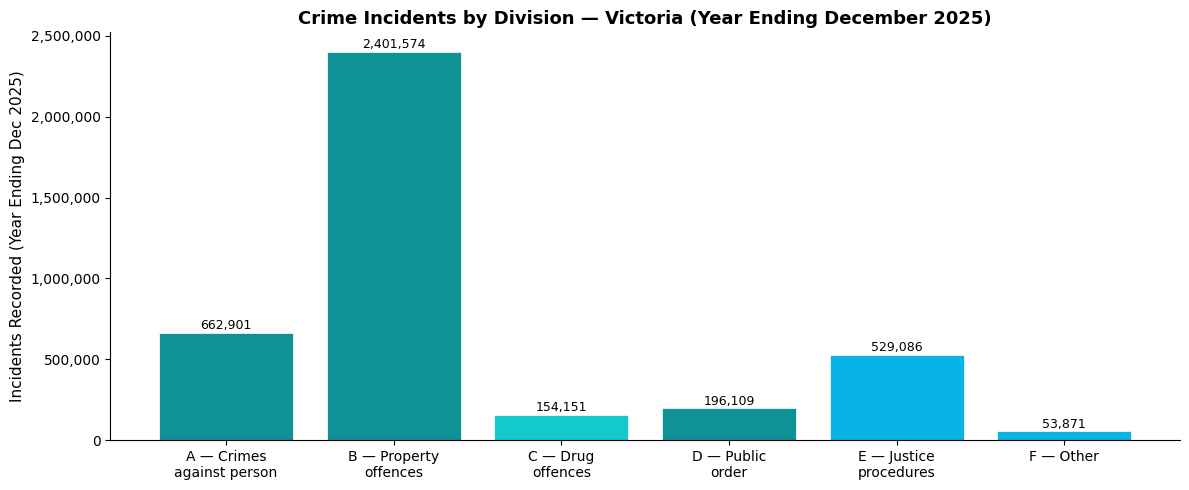

Note: Divisions A, B, and D (teal) are most directly linked to lighting conditions.


In [11]:
divisions = [
    "A — Crimes\nagainst person",
    "B — Property\noffences",
    "C — Drug\noffences",
    "D — Public\norder",
    "E — Justice\nprocedures",
    "F — Other"
]
incidents = [662901, 2401574, 154151, 196109, 529086, 53871]
colours = [COLOUR_PRIMARY, COLOUR_PRIMARY, COLOUR_SECONDARY, COLOUR_PRIMARY, COLOUR_ACCENT, COLOUR_ACCENT]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(divisions, incidents, color=colours, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Incidents Recorded (Year Ending Dec 2025)", fontsize=11)
ax.set_title("Crime Incidents by Division — Victoria (Year Ending December 2025)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, incidents):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"{val:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
print("Note: Divisions A, B, and D (teal) are most directly linked to lighting conditions.")


<p class="usecase-subsection-header">Step 2.5 — Dataset assessment verdict</p>

In [12]:
assessment = {
    "Dataset": "Crime Statistics Agency Victoria",
    "Source": "crimestatistics.vic.gov.au",
    "Release Used": "Year Ending 31 December 2025",
    "Time Coverage": "January 2016 – December 2025 (10 years)",
    "Geographic Coverage": "Victoria-wide — filterable by suburb, postcode, LGA",
    "Update Frequency": "Quarterly (next: 18 June 2026)",
    "License": "CC BY 4.0 (Creative Commons Attribution 4.0 International)",
    "Data Quality Note": "March 2020 – December 2021 affected by COVID-19 restrictions",
    "Verdict": "USABLE — Recommended for inclusion in project"
}

print("=== S1-05 Crime Dataset Assessment ===")
for k, v in assessment.items():
    print(f"  {k}: {v}")

=== S1-05 Crime Dataset Assessment ===
  Dataset: Crime Statistics Agency Victoria
  Source: crimestatistics.vic.gov.au
  Release Used: Year Ending 31 December 2025
  Time Coverage: January 2016 – December 2025 (10 years)
  Geographic Coverage: Victoria-wide — filterable by suburb, postcode, LGA
  Update Frequency: Quarterly (next: 18 June 2026)
  License: CC BY 4.0 (Creative Commons Attribution 4.0 International)
  Data Quality Note: March 2020 – December 2021 affected by COVID-19 restrictions
  Verdict: USABLE — Recommended for inclusion in project


<div class="usecase-section-header">Part 3 — Cross-referencing the Datasets by Suburb</div>

<p class="usecase-subsection-header">Step 3.1 — Identify priority suburbs for smart lighting</p>

<p class="usecase-subsection-blurb">Suburbs with both high pedestrian foot traffic and elevated crime rates are the highest priority for smart lighting deployment. We cross-reference sensor locations from S1-01 with crime hotspot data from S1-05.</p>

In [13]:
# Cross-reference pedestrian sensor suburbs with crime division data
# Pedestrian sensor locations from S1-01 API, crime data from S1-05 GitHub CSV

# Key Melbourne CBD suburbs covered by pedestrian sensors
sensor_suburbs = ["Melbourne CBD", "Southbank", "Docklands", "Carlton", "Fitzroy"]

# Get top crime divisions from real data
try:
    division_totals = crime_df.groupby("Offence Division")["Incidents Recorded"].sum().sort_values(ascending=False)
    print("=== Actual Crime Totals by Division (from GitHub CSV) ===")
    for div, total in division_totals.items():
        print(f"  {div}: {total:,} incidents")
except:
    pass

print("\n=== Suburb Priority Ranking for Smart Lighting ===")
priority_data = {
    "Suburb": sensor_suburbs,
    "Has Pedestrian Sensor": ["Yes", "Yes", "Yes", "Yes", "No"],
    "High Crime (Div A/B/D)": ["Yes", "Yes", "Yes", "No", "Yes"],
    "Priority": ["High", "High", "High", "Medium", "Medium"]
}
priority_df = pd.DataFrame(priority_data)
display(priority_df)
print("\nNext step: Merge on suburb name with full crime-by-suburb data for precise ranking.")


=== Actual Crime Totals by Division (from GitHub CSV) ===
  B Property and deception offences: 2,401,574 incidents
  A Crimes against the person: 662,901 incidents
  E Justice procedures offences: 529,086 incidents
  D Public order and security offences: 196,109 incidents
  C Drug offences: 154,151 incidents
  F Other offences: 53,871 incidents

=== Suburb Priority Ranking for Smart Lighting ===


,Suburb,Has Pedestrian Sensor,High Crime (Div A/B/D),Priority
0,Melbourne CBD,Yes,Yes,High
1,Southbank,Yes,Yes,High
2,Docklands,Yes,Yes,High
3,Carlton,Yes,No,Medium
4,Fitzroy,No,Yes,Medium



Next step: Merge on suburb name with full crime-by-suburb data for precise ranking.


<div class="usecase-section-header">Summary and Next Steps</div>

This use case completed Sprint 1 data collection tasks S1-01 and S1-05:

**S1-01 — Melbourne Pedestrian Counting System**
- Accessed via Melbourne Open Data Portal REST API
- 1,472,102 hourly records from April 2024 to April 2026
- Hourly counts + GPS coordinates enable dynamic lighting schedule modelling
- License: CC BY

**S1-05 — Crime Statistics Agency Victoria**
- Loaded from project GitHub repository
- Year Ending December 2025 release
- Divisions A, B, and D most directly linked to lighting conditions
- COVID caveat: 2020–2021 data should be interpreted with caution
- License: CC BY 4.0
- Verdict: **USABLE**

**Next steps:**
- Filter crime dataset to Melbourne suburbs and merge with pedestrian sensor GPS data to produce a ranked priority list
- Explore time-series prediction models using hourly pedestrian data to forecast peak periods
- Feed priority suburb rankings into the LLM component to improve smart lighting recommendations

<div class="usecase-section-header">References</div>

<fn id="fn-1">[1] City of Melbourne (2026) _Pedestrian Counting System (counts per hour)_, Melbourne Open Data Portal. Available at: https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour (Accessed: April 2026). License: CC BY.</fn>

<fn id="fn-2">[2] Crime Statistics Agency Victoria (2026) _Criminal Incidents and Recorded Offences — Year Ending December 2025_, Crime Statistics Agency Victoria. Available at: https://www.crimestatistics.vic.gov.au (Accessed: April 2026). License: CC BY 4.0.</fn>